# Speech Emotion Recognition (SER) using RAVDESS
**Objective:** Classify human emotions (Neutral, Calm, Happy, Sad, Angry, Fearful, Disgust, Surprised) from speech audio signals using Deep Learning.

### 1.1 Import Required Libraries

In [4]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, Dropout, LSTM, Input, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

/Users/lokeshchhajer/Documents/code-alpha/project-2/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


### 2.1 Parse RAVDESS File Paths and Labels
The RAVDESS dataset uses a strict naming convention:
`Modality-VocalChannel-Emotion-EmotionalIntensity-Statement-Repetition-Actor.wav`
*Emotion identifier is the 3rd part (e.g., 01 = neutral, 03 = happy, etc.)*

Total audio files loaded: 2880


/var/folders/mf/gm32wmfd2kz2ml0pcdh6pg4c0000gn/T/ipykernel_86811/3344337075.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='emotion', order=df['emotion'].value_counts().index, palette='viridis')


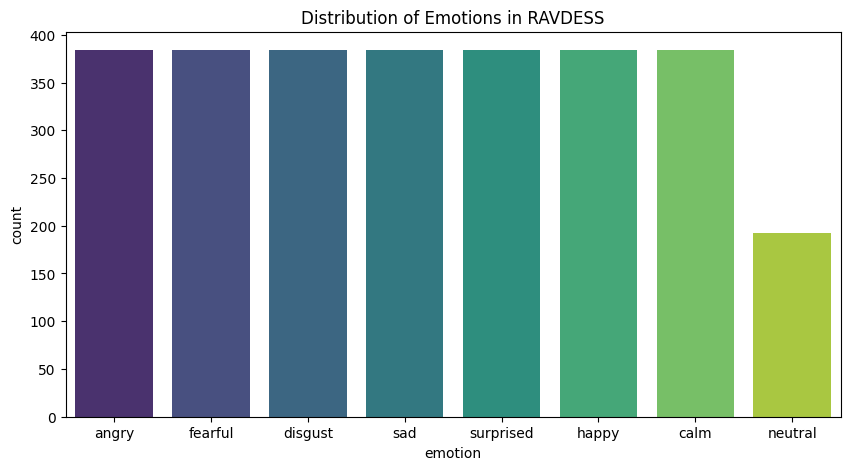

In [6]:
# Emotion mapping based on RAVDESS documentation
emotion_map = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

def load_dataset(dataset_path):
    file_paths = []
    labels = []
    
    for dirname, _, filenames in os.walk(dataset_path):
        for filename in filenames:
            if filename.endswith('.wav'):
                file_path = os.path.join(dirname, filename)
                # Extract emotion code from filename
                parts = filename.split('-')
                if len(parts) == 7:
                    emotion_code = parts[2]
                    emotion = emotion_map.get(emotion_code)
                    if emotion:
                        file_paths.append(file_path)
                        labels.append(emotion)
                        
    return pd.DataFrame({'filepath': file_paths, 'emotion': labels})

# TODO: Replace with your actual dataset path
DATASET_PATH = "dataset/" 
df = load_dataset(DATASET_PATH)
print(f"Total audio files loaded: {len(df)}")

# Display Class Distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='emotion', order=df['emotion'].value_counts().index, palette='viridis')
plt.title('Distribution of Emotions in RAVDESS')
plt.show()

### 3.1 Extract Temporal & Spectral Features
We extract frame-level features (MFCC, Chroma, Mel Spectrogram, ZCR, RMS) and pad/truncate sequences to a fixed length (e.g., 150 frames, roughly ~3 seconds) for sequential modeling.

In [7]:
def extract_features_sequence(file_path, max_len=150, sr=22050):
    try:
        y, sample_rate = librosa.load(file_path, sr=sr)
        # Trim leading and trailing silence
        y, _ = librosa.effects.trim(y)
        
        # 1. MFCCs (Time, 40)
        mfcc = librosa.feature.mfcc(y=y, sr=sample_rate, n_mfcc=40).T
        # 2. Chroma (Time, 12)
        chroma = librosa.feature.chroma_stft(y=y, sr=sample_rate).T
        # 3. Mel Spectrogram (Time, 128)
        mel = librosa.feature.melspectrogram(y=y, sr=sample_rate).T
        # 4. Zero Crossing Rate (Time, 1)
        zcr = librosa.feature.zero_crossing_rate(y=y).T
        # 5. RMS Energy (Time, 1)
        rms = librosa.feature.rms(y=y).T
        
        # Concatenate features along the feature axis -> Shape: (Time, 182)
        features = np.hstack([mfcc, chroma, mel, zcr, rms])
        
        # Pad or Truncate to uniform length (max_len)
        if features.shape[0] < max_len:
            pad_width = max_len - features.shape[0]
            features = np.pad(features, pad_width=((0, pad_width), (0, 0)), mode='constant')
        else:
            features = features[:max_len, :]
            
        return features
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# Apply feature extraction
print("Extracting features (this may take a few minutes)...")
X = []
for path in df['filepath']:
    features = extract_features_sequence(path)
    X.append(features)

X = np.array(X)
print(f"Feature matrix shape: {X.shape}") # Expected: (Samples, 150, 182)

Extracting features (this may take a few minutes)...
Feature matrix shape: (2880, 150, 182)


### 4.1 Visualizing Audio Signals (Time & Frequency Domains)

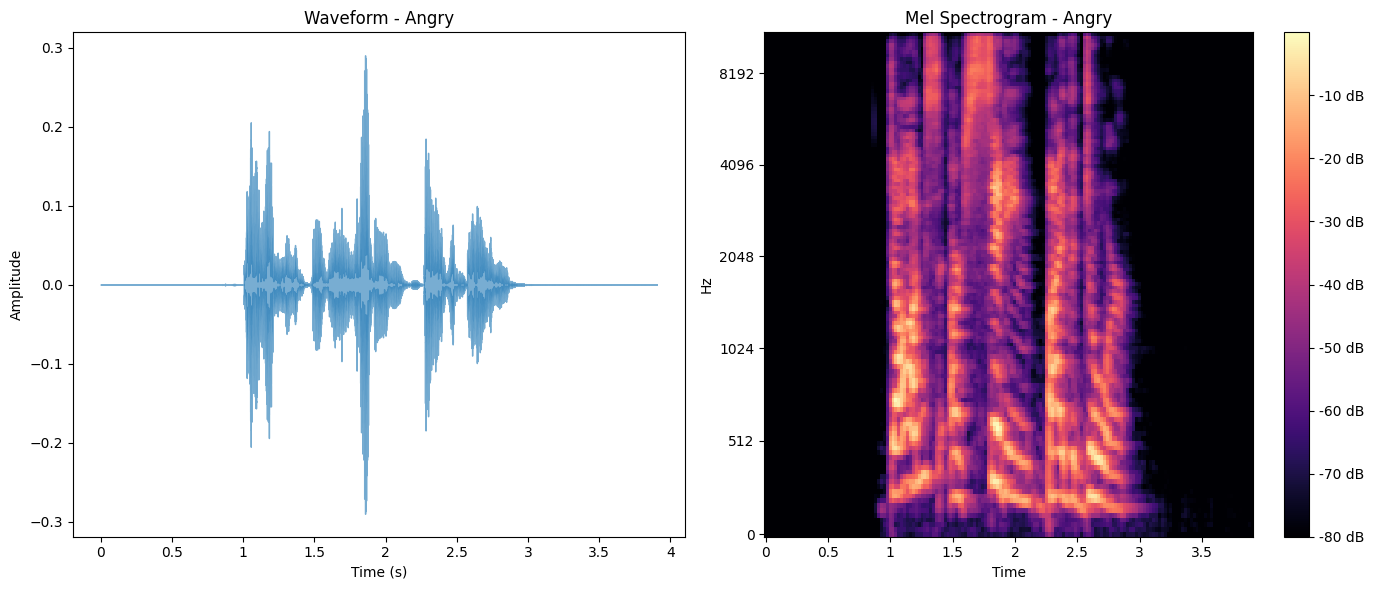

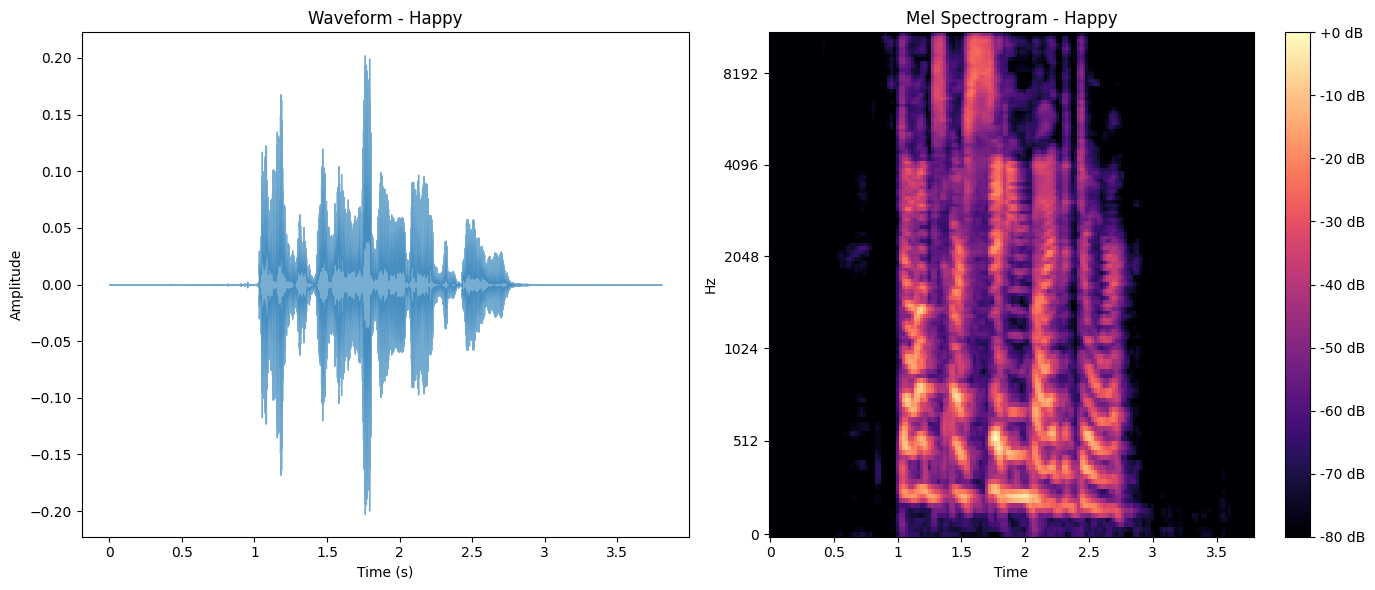

In [8]:
def plot_audio_features(file_path, emotion):
    y, sr = librosa.load(file_path, sr=22050)
    
    plt.figure(figsize=(14, 6))
    
    # 1. Waveform
    plt.subplot(1, 2, 1)
    librosa.display.waveshow(y, sr=sr, alpha=0.6)
    plt.title(f'Waveform - {emotion.capitalize()}')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    
    # 2. Mel Spectrogram
    plt.subplot(1, 2, 2)
    mel = librosa.feature.melspectrogram(y=y, sr=sr)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f'Mel Spectrogram - {emotion.capitalize()}')
    
    plt.tight_layout()
    plt.show()

# Visualize an example from 'Angry' and 'Happy' classes
for emotion in ['angry', 'happy']:
    sample_file = df[df['emotion'] == emotion].iloc[0]['filepath']
    plot_audio_features(sample_file, emotion)

### 5.1 Encode Labels, Scale Features, and Split Data
Because `X` is a 3D array `(Samples, Time_Steps, Features)`, we reshape it to 2D for the `StandardScaler`, and then reshape it back to 3D for the deep learning models.

In [9]:
# Label Encoding
le = LabelEncoder()
y = le.fit_transform(df['emotion'])
y_cat = tf.keras.utils.to_categorical(y)

# Standardization across the feature dimension
samples, time_steps, num_features = X.shape
X_reshaped = X.reshape(-1, num_features) # Reshape to 2D

scaler = StandardScaler()
X_scaled_reshaped = scaler.fit_transform(X_reshaped)

X_scaled = X_scaled_reshaped.reshape(samples, time_steps, num_features) # Back to 3D

# Train, Validation, Test Split (70-15-15)
X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y_cat, test_size=0.3, random_state=42, stratify=y_cat)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (2016, 150, 182)
X_val shape: (432, 150, 182)
X_test shape: (432, 150, 182)


### 6.1 Define Convolutional Neural Network (1D CNN) and LSTM

In [10]:
input_shape = (time_steps, num_features)
num_classes = len(le.classes_)

def build_cnn_model():
    model = Sequential([
        Conv1D(filters=128, kernel_size=5, activation='relu', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        
        Conv1D(filters=256, kernel_size=5, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.4),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

def build_lstm_model():
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=input_shape),
        Dropout(0.3),
        LSTM(64),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# Initialize Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
callbacks = [early_stopping, lr_scheduler]

# Train CNN Model
print("Training 1D CNN Model...")
cnn_model = build_cnn_model()
history_cnn = cnn_model.fit(
    X_train, y_train, 
    validation_data=(X_val, y_val),
    epochs=50, batch_size=32, 
    callbacks=callbacks, verbose=1
)

# Train LSTM Model
print("\nTraining LSTM Model...")
lstm_model = build_lstm_model()
history_lstm = lstm_model.fit(
    X_train, y_train, 
    validation_data=(X_val, y_val),
    epochs=50, batch_size=32, 
    callbacks=callbacks, verbose=1
)

Training 1D CNN Model...


/Users/lokeshchhajer/Documents/code-alpha/project-2/.venv/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-08-09 02:51:46.021094: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-08-09 02:51:46.021391: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-08-09 02:51:46.021405: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-08-09 02:51:46.021694: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-09 02:51:46.021723: I tensorflow/core/common_runtime/pluggable

Epoch 1/50


2026-08-09 02:51:48.364582: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.2159 - loss: 9.4952 - val_accuracy: 0.1620 - val_loss: 14.8993 - learning_rate: 0.0010
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.3050 - loss: 13.6962 - val_accuracy: 0.4074 - val_loss: 4.1593 - learning_rate: 0.0010
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.3788 - loss: 11.1217 - val_accuracy: 0.5255 - val_loss: 3.5417 - learning_rate: 0.0010
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.4116 - loss: 11.2814 - val_accuracy: 0.5046 - val_loss: 5.3599 - learning_rate: 0.0010
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.4872 - loss: 9.5284 - val_accuracy: 0.5440 - val_loss: 6.1572 - learning_rate: 0.0010
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.5079 - loss: 10.5543 - val_accuracy: 0.5417 - val_loss: 6.0885 - learning_rate: 0.0010
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.5689 - loss: 7.9874 - val_accuracy

/Users/lokeshchhajer/Documents/code-alpha/project-2/.venv/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - accuracy: 0.1907 - loss: 2.0287 - val_accuracy: 0.1620 - val_loss: 1.9832 - learning_rate: 0.0010
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.2692 - loss: 1.9096 - val_accuracy: 0.3148 - val_loss: 1.8381 - learning_rate: 0.0010
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.3339 - loss: 1.7841 - val_accuracy: 0.3426 - val_loss: 1.7023 - learning_rate: 0.0010
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.3728 - loss: 1.6536 - val_accuracy: 0.3796 - val_loss: 1.7196 - learning_rate: 0.0010
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.3744 - loss: 1.6669 - val_accuracy: 0.4259 - val_loss: 1.5185 - learning_rate: 0.0010
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.4389 - loss: 1.5386 - val_accuracy: 0.3889 - val_loss: 1.5504 - learning_rate: 0.0010
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.4492 - loss: 1.4673 - val_acc

### 7.1 Performance Comparison & Confusion Matrix

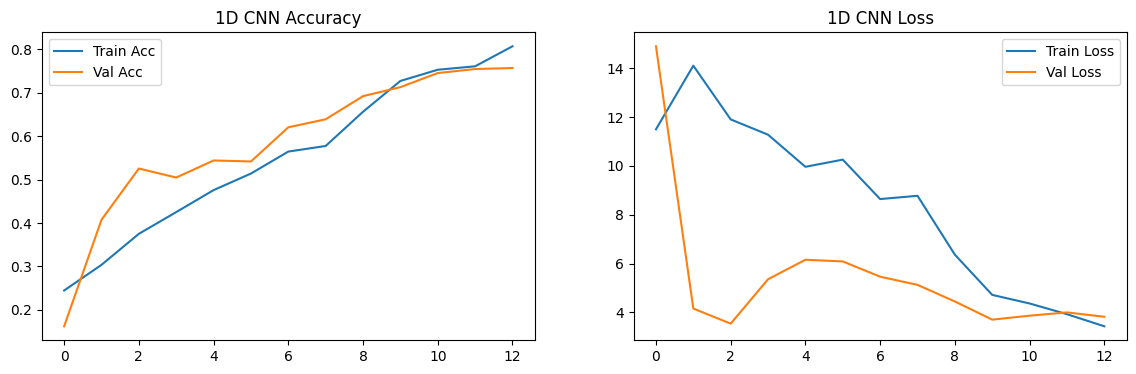

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

Classification Report for 1D CNN:

              precision    recall  f1-score   support

       angry       0.61      0.62      0.62        58
        calm       0.45      0.82      0.58        57
     disgust       0.65      0.45      0.53        58
     fearful       0.69      0.41      0.52        58
       happy       0.51      0.57      0.54        58
     neutral       0.24      0.34      0.29        29
         sad       0.53      0.32      0.40        57
   surprised       0.64      0.60      0.62        57

    accuracy                           0.53       432
   macro avg       0.54      0.52      0.51       432
weighted avg       0.56      0.53      0.52       432



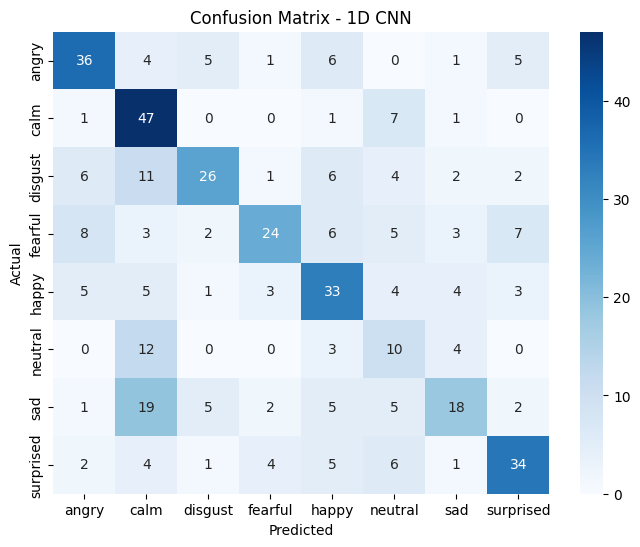

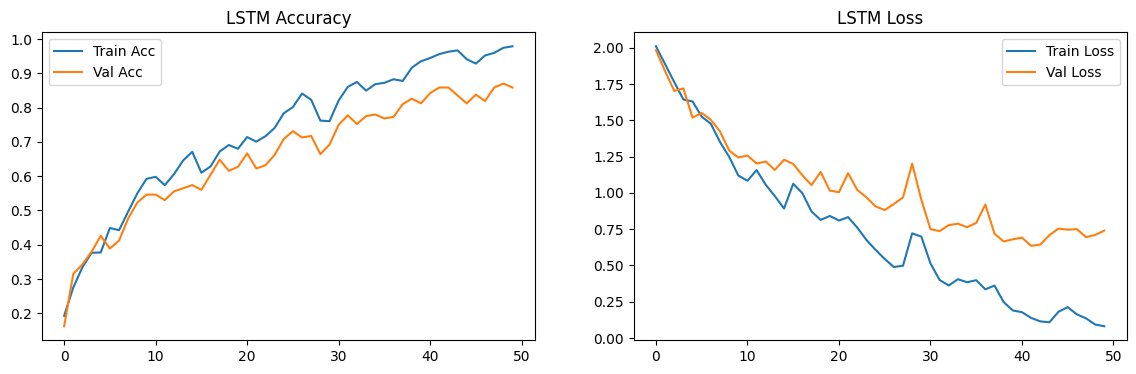

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step

Classification Report for LSTM:

              precision    recall  f1-score   support

       angry       0.91      0.88      0.89        58
        calm       0.90      0.93      0.91        57
     disgust       0.82      0.95      0.88        58
     fearful       0.94      0.88      0.91        58
       happy       0.87      0.91      0.89        58
     neutral       0.72      0.72      0.72        29
         sad       0.90      0.77      0.83        57
   surprised       0.91      0.91      0.91        57

    accuracy                           0.88       432
   macro avg       0.87      0.87      0.87       432
weighted avg       0.88      0.88      0.88       432



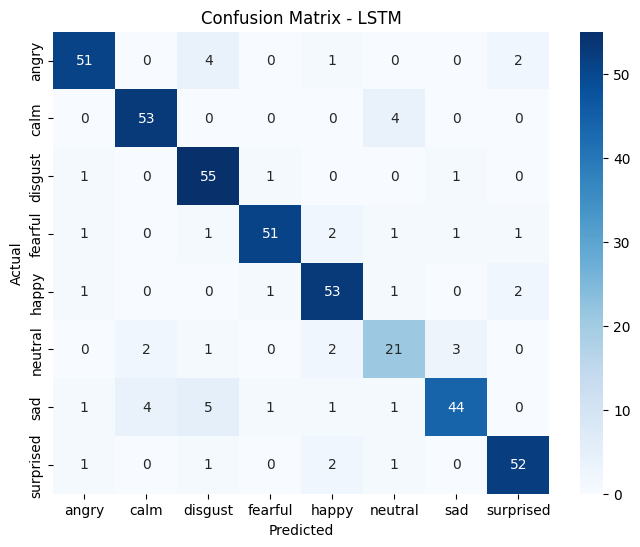

In [11]:
def evaluate_model(model, history, name="Model"):
    # Plot Accuracy and Loss
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(history.history['accuracy'], label='Train Acc')
    axes[0].plot(history.history['val_accuracy'], label='Val Acc')
    axes[0].set_title(f'{name} Accuracy')
    axes[0].legend()
    
    axes[1].plot(history.history['loss'], label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Val Loss')
    axes[1].set_title(f'{name} Loss')
    axes[1].legend()
    plt.show()

    # Predictions
    y_pred = np.argmax(model.predict(X_test), axis=1)
    y_true = np.argmax(y_test, axis=1)
    
    # Classification Report
    print(f"\nClassification Report for {name}:\n")
    print(classification_report(y_true, y_pred, target_names=le.classes_))
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

evaluate_model(cnn_model, history_cnn, "1D CNN")
evaluate_model(lstm_model, history_lstm, "LSTM")

### 8.1 Save Best Model and Preprocessing Objects
Assuming the 1D CNN performed best, we will export it.

In [12]:
# Save the model
cnn_model.save('best_emotion_model.keras')

# Save Scaler and Label Encoder
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(le, 'label_encoder.joblib')

print("Artifacts saved successfully. Ready for deployment!")

Artifacts saved successfully. Ready for deployment!
